In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
X_train = joblib.load("../models/X_train_processed.joblib")
X_test = joblib.load("../models/X_test_processed.joblib")

y_train = joblib.load("../models/y_train.joblib")
y_test = joblib.load("../models/y_test.joblib")

print("Processed data loaded successfully")

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Processed data loaded successfully

X_train shape: (41413, 112)
X_test shape : (10354, 112)
y_train shape: (41413,)
y_test shape : (10354,)


In [3]:
print("X_train type:", type(X_train))
print("X_test type :", type(X_test))

print("y_train type:", type(y_train))
print("y_test type :", type(y_test))

X_train type: <class 'scipy.sparse._csr.csr_matrix'>
X_test type : <class 'scipy.sparse._csr.csr_matrix'>
y_train type: <class 'pandas.Series'>
y_test type : <class 'pandas.Series'>


In [4]:
print("Training target statistics:")
print(y_train.describe())

Training target statistics:
count    4.141300e+04
mean     2.037981e+07
std      3.562228e+07
min      3.200000e+04
25%      6.500000e+06
50%      1.200034e+07
75%      2.210000e+07
max      2.147484e+09
Name: price, dtype: float64


In [5]:
def evaluate_model(model_name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return {
        "Model": model_name,
        "R2 Score": r2,
        "MSE": mse,
        "RMSE": rmse
    }


print("Evaluation function created successfully")

Evaluation function created successfully


In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully")

Linear Regression trained successfully


In [7]:
linear_result = evaluate_model(
    "Linear Regression",
    linear_model,
    X_test,
    y_test
)

print(linear_result)

{'Model': 'Linear Regression', 'R2 Score': 0.655706634552479, 'MSE': 322136679453359.75, 'RMSE': np.float64(17948166.464944538)}


In [8]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

print("Ridge Regression trained successfully")

Ridge Regression trained successfully


In [9]:
ridge_result = evaluate_model(
    "Ridge Regression",
    ridge_model,
    X_test,
    y_test
)

print(ridge_result)

{'Model': 'Ridge Regression', 'R2 Score': 0.6561153346710666, 'MSE': 321754280858711.06, 'RMSE': np.float64(17937510.442051623)}


In [10]:
lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_model.fit(X_train, y_train)

print("Lasso Regression trained successfully")

Lasso Regression trained successfully


c:\Users\Tejas Dalvi\anaconda3\anaconda\envs\mumbai-house\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.978073e+18, tolerance: 5.255e+15
  model = cd_fast.sparse_enet_coordinate_descent(


In [11]:
lasso_result = evaluate_model(
    "Lasso Regression",
    lasso_model,
    X_test,
    y_test
)

print(lasso_result)

{'Model': 'Lasso Regression', 'R2 Score': 0.6559048787285389, 'MSE': 321951193100714.3, 'RMSE': np.float64(17942998.44230931)}


In [12]:
random_forest_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [13]:
random_forest_result = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

print(random_forest_result)

{'Model': 'Random Forest', 'R2 Score': 0.8151321243074132, 'MSE': 172970871906864.38, 'RMSE': np.float64(13151839.107397275)}


In [14]:
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully")

Gradient Boosting trained successfully


In [15]:
gradient_boosting_result = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_model,
    X_test,
    y_test
)

print(gradient_boosting_result)

{'Model': 'Gradient Boosting', 'R2 Score': 0.7720864857512058, 'MSE': 213246347594355.66, 'RMSE': np.float64(14602956.80998734)}


In [16]:
results = [
    linear_result,
    ridge_result,
    lasso_result,
    random_forest_result,
    gradient_boosting_result
]

results_df = pd.DataFrame(results)

results_df

,Model,R2 Score,MSE,RMSE
0,Linear Regression,0.655707,3.221367e+14,1.794817e+07
1,Ridge Regression,0.656115,3.217543e+14,1.793751e+07
2,Lasso Regression,0.655905,3.219512e+14,1.794300e+07
3,Random Forest,0.815132,1.729709e+14,1.315184e+07
4,Gradient Boosting,0.772086,2.132463e+14,1.460296e+07


In [17]:
results_by_r2 = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_by_r2

,Model,R2 Score,MSE,RMSE
0,Random Forest,0.815132,1.729709e+14,1.315184e+07
1,Gradient Boosting,0.772086,2.132463e+14,1.460296e+07
2,Ridge Regression,0.656115,3.217543e+14,1.793751e+07
3,Lasso Regression,0.655905,3.219512e+14,1.794300e+07
4,Linear Regression,0.655707,3.221367e+14,1.794817e+07


In [18]:
results_by_rmse = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

results_by_rmse

,Model,R2 Score,MSE,RMSE
0,Random Forest,0.815132,1.729709e+14,1.315184e+07
1,Gradient Boosting,0.772086,2.132463e+14,1.460296e+07
2,Ridge Regression,0.656115,3.217543e+14,1.793751e+07
3,Lasso Regression,0.655905,3.219512e+14,1.794300e+07
4,Linear Regression,0.655707,3.221367e+14,1.794817e+07


In [22]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original target mean:", y_train.mean())
print("Log target mean     :", y_train_log.mean())

print("\nLog transformation completed")

Original target mean: 20379812.301861733
Log target mean     : 16.338447303505514

Log transformation completed


In [23]:
print("Original target:")
print(y_train.head())

print("\nLog-transformed target:")
print(y_train_log.head())

Original target:
44125    36900000
29496     3174000
41546    12590000
15247    16200000
42780    27500000
Name: price, dtype: int64

Log-transformed target:
44125    17.423722
29496    14.970503
41546    16.348413
15247    16.600522
42780    17.129697
Name: price, dtype: float64


In [24]:
linear_log_model = LinearRegression()

linear_log_model.fit(
    X_train,
    y_train_log
)

print("Log Linear Regression trained successfully")

Log Linear Regression trained successfully


In [27]:
log_linear_predictions = linear_log_model.predict(X_test)

linear_log_predictions_original = np.expm1(
    log_linear_predictions
)

linear_log_mse = mean_squared_error(
    y_test,
    linear_log_predictions_original
)

linear_log_rmse = np.sqrt(linear_log_mse)

linear_log_r2 = r2_score(
    y_test,
    linear_log_predictions_original
)

linear_log_result = {
    "Model": "Log Linear Regression",
    "R2 Score": linear_log_r2,
    "MSE": linear_log_mse,
    "RMSE": linear_log_rmse
}

print(linear_log_result)

{'Model': 'Log Linear Regression', 'R2 Score': 0.48710593651298895, 'MSE': 479887233110887.3, 'RMSE': np.float64(21906328.60866666)}


In [28]:
ridge_log_model = Ridge(alpha=1.0)

ridge_log_model.fit(
    X_train,
    y_train_log
)

print("Log Ridge Regression trained successfully")

Log Ridge Regression trained successfully


In [29]:
ridge_log_predictions = ridge_log_model.predict(X_test)

ridge_log_predictions_original = np.expm1(
    ridge_log_predictions
)

ridge_log_mse = mean_squared_error(
    y_test,
    ridge_log_predictions_original
)

ridge_log_rmse = np.sqrt(ridge_log_mse)

ridge_log_r2 = r2_score(
    y_test,
    ridge_log_predictions_original
)

ridge_log_result = {
    "Model": "Log Ridge Regression",
    "R2 Score": ridge_log_r2,
    "MSE": ridge_log_mse,
    "RMSE": ridge_log_rmse
}

print(ridge_log_result)

{'Model': 'Log Ridge Regression', 'R2 Score': 0.4844677832371399, 'MSE': 482355610435168.25, 'RMSE': np.float64(21962595.712601192)}


In [30]:
random_forest_log_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

random_forest_log_model.fit(
    X_train,
    y_train_log
)

print("Log Random Forest trained successfully")

Log Random Forest trained successfully


In [31]:
rf_log_predictions = random_forest_log_model.predict(X_test)

rf_log_predictions_original = np.expm1(
    rf_log_predictions
)

rf_log_mse = mean_squared_error(
    y_test,
    rf_log_predictions_original
)

rf_log_rmse = np.sqrt(rf_log_mse)

rf_log_r2 = r2_score(
    y_test,
    rf_log_predictions_original
)

rf_log_result = {
    "Model": "Log Random Forest",
    "R2 Score": rf_log_r2,
    "MSE": rf_log_mse,
    "RMSE": rf_log_rmse
}

print(rf_log_result)

{'Model': 'Log Random Forest', 'R2 Score': 0.8382623615922855, 'MSE': 151329159978341.03, 'RMSE': np.float64(12301591.766041541)}


In [32]:
gradient_boosting_log_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_log_model.fit(
    X_train,
    y_train_log
)

print("Log Gradient Boosting trained successfully")

Log Gradient Boosting trained successfully


In [33]:
gb_log_predictions = gradient_boosting_log_model.predict(X_test)

gb_log_predictions_original = np.expm1(
    gb_log_predictions
)

gb_log_mse = mean_squared_error(
    y_test,
    gb_log_predictions_original
)

gb_log_rmse = np.sqrt(gb_log_mse)

gb_log_r2 = r2_score(
    y_test,
    gb_log_predictions_original
)

gb_log_result = {
    "Model": "Log Gradient Boosting",
    "R2 Score": gb_log_r2,
    "MSE": gb_log_mse,
    "RMSE": gb_log_rmse
}

print(gb_log_result)

{'Model': 'Log Gradient Boosting', 'R2 Score': 0.7755388015665324, 'MSE': 210016202419388.1, 'RMSE': np.float64(14491935.771986712)}


In [34]:
all_results = [
    linear_result,
    ridge_result,
    lasso_result,
    random_forest_result,
    gradient_boosting_result,
    linear_log_result,
    ridge_log_result,
    rf_log_result,
    gb_log_result
]

all_results_df = pd.DataFrame(all_results)

all_results_df

,Model,R2 Score,MSE,RMSE
0,Linear Regression,0.655707,3.221367e+14,1.794817e+07
1,Ridge Regression,0.656115,3.217543e+14,1.793751e+07
2,Lasso Regression,0.655905,3.219512e+14,1.794300e+07
3,Random Forest,0.815132,1.729709e+14,1.315184e+07
4,Gradient Boosting,0.772086,2.132463e+14,1.460296e+07
5,Log Linear Regression,0.487106,4.798872e+14,2.190633e+07
6,Log Ridge Regression,0.484468,4.823556e+14,2.196260e+07
7,Log Random Forest,0.838262,1.513292e+14,1.230159e+07
8,Log Gradient Boosting,0.775539,2.100162e+14,1.449194e+07


In [35]:
final_comparison = all_results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,R2 Score,MSE,RMSE
0,Log Random Forest,0.838262,1.513292e+14,1.230159e+07
1,Random Forest,0.815132,1.729709e+14,1.315184e+07
2,Log Gradient Boosting,0.775539,2.100162e+14,1.449194e+07
3,Gradient Boosting,0.772086,2.132463e+14,1.460296e+07
4,Ridge Regression,0.656115,3.217543e+14,1.793751e+07
5,Lasso Regression,0.655905,3.219512e+14,1.794300e+07
6,Linear Regression,0.655707,3.221367e+14,1.794817e+07
7,Log Linear Regression,0.487106,4.798872e+14,2.190633e+07
8,Log Ridge Regression,0.484468,4.823556e+14,2.196260e+07


In [36]:
final_rmse_comparison = all_results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

final_rmse_comparison

,Model,R2 Score,MSE,RMSE
0,Log Random Forest,0.838262,1.513292e+14,1.230159e+07
1,Random Forest,0.815132,1.729709e+14,1.315184e+07
2,Log Gradient Boosting,0.775539,2.100162e+14,1.449194e+07
3,Gradient Boosting,0.772086,2.132463e+14,1.460296e+07
4,Ridge Regression,0.656115,3.217543e+14,1.793751e+07
5,Lasso Regression,0.655905,3.219512e+14,1.794300e+07
6,Linear Regression,0.655707,3.221367e+14,1.794817e+07
7,Log Linear Regression,0.487106,4.798872e+14,2.190633e+07
8,Log Ridge Regression,0.484468,4.823556e+14,2.196260e+07


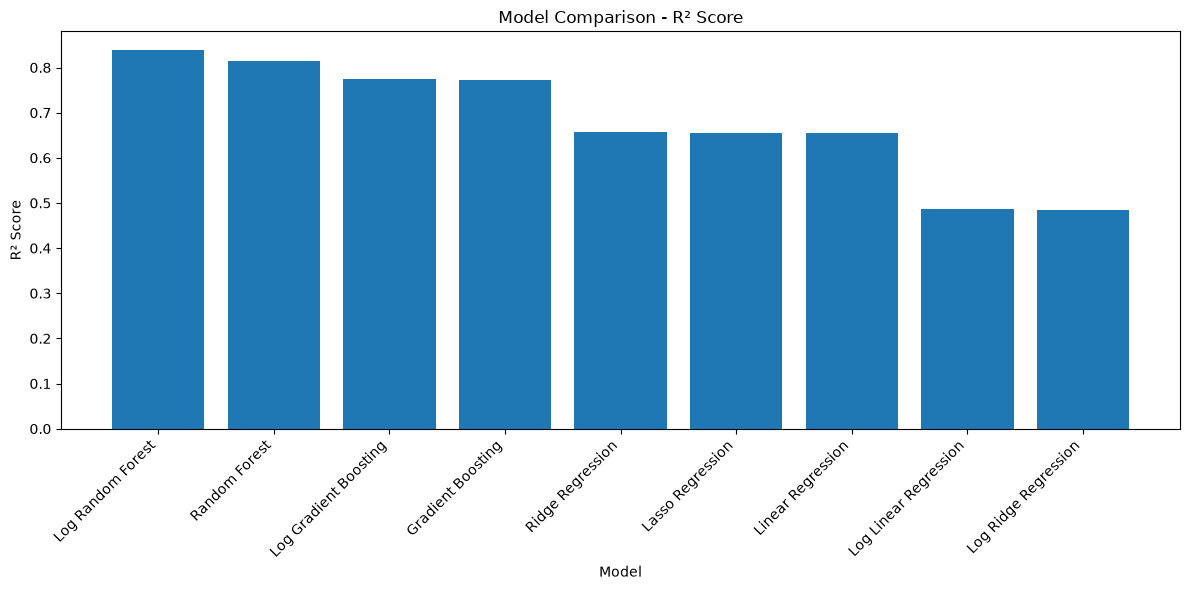

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

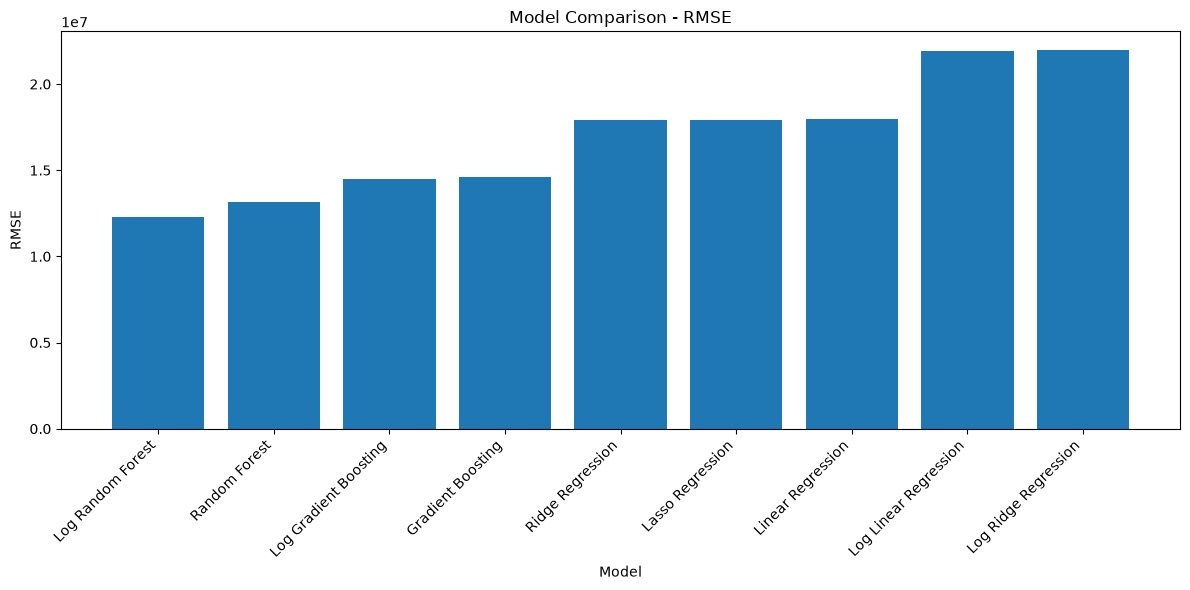

In [38]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_rmse_comparison["Model"],
    final_rmse_comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [39]:
best_model_name = final_comparison.iloc[0]["Model"]
best_r2 = final_comparison.iloc[0]["R2 Score"]
best_rmse = final_comparison.iloc[0]["RMSE"]

print("Best model according to test-set R²:")
print(best_model_name)

print("\nR² Score:", best_r2)
print("RMSE:", best_rmse)

Best model according to test-set R²:
Log Random Forest

R² Score: 0.8382623615922855
RMSE: 12301591.766041541


In [40]:
models = {
    "linear_model": linear_model,
    "ridge_model": ridge_model,
    "lasso_model": lasso_model,
    "random_forest_model": random_forest_model,
    "gradient_boosting_model": gradient_boosting_model,
    "linear_log_model": linear_log_model,
    "ridge_log_model": ridge_log_model,
    "random_forest_log_model": random_forest_log_model,
    "gradient_boosting_log_model": gradient_boosting_log_model
}

for model_name, model in models.items():
    file_path = f"../models/{model_name}.joblib"
    joblib.dump(model, file_path)
    print("Saved:", file_path)

Saved: ../models/linear_model.joblib
Saved: ../models/ridge_model.joblib
Saved: ../models/lasso_model.joblib
Saved: ../models/random_forest_model.joblib
Saved: ../models/gradient_boosting_model.joblib
Saved: ../models/linear_log_model.joblib
Saved: ../models/ridge_log_model.joblib
Saved: ../models/random_forest_log_model.joblib
Saved: ../models/gradient_boosting_log_model.joblib


In [41]:
all_results_df.to_csv(
    "../models/model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully")

Model comparison results saved successfully


In [42]:
import os

print("Saved model files:")

for model_name in models.keys():
    file_path = f"../models/{model_name}.joblib"
    
    if os.path.exists(file_path):
        print("✓", model_name)
    else:
        print("✗", model_name)

print("\nComparison file:")

if os.path.exists("../models/model_comparison_results.csv"):
    print("✓ model_comparison_results.csv")
else:
    print("✗ model_comparison_results.csv")

Saved model files:
✓ linear_model
✓ ridge_model
✓ lasso_model
✓ random_forest_model
✓ gradient_boosting_model
✓ linear_log_model
✓ ridge_log_model
✓ random_forest_log_model
✓ gradient_boosting_log_model

Comparison file:
✓ model_comparison_results.csv


In [43]:
loaded_model = joblib.load(
    "../models/random_forest_model.joblib"
)

test_predictions = loaded_model.predict(X_test)

print("Loaded model successfully")

print("\nFirst 10 actual prices:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted prices:")
print(test_predictions[:10])

Loaded model successfully

First 10 actual prices:
[39500000 16500000 75000000  1851000 18000000  8000000 16000000  3800000
 15000000 16957615]

First 10 predicted prices:
[39804946.76       19180473.33333333 67221278.49555555  2442610.82
 18619637.45222222  7343470.26666667 15905923.58888889  4310425.
 16783003.74666667 16234706.48333333]


In [44]:
print("=" * 65)
print("MODEL TRAINING COMPLETED")
print("=" * 65)

print("\nModels trained:")
print("1. Linear Regression")
print("2. Ridge Regression")
print("3. Lasso Regression")
print("4. Random Forest Regression")
print("5. Gradient Boosting Regression")

print("\nLog-transformed models:")
print("6. Log Linear Regression")
print("7. Log Ridge Regression")
print("8. Log Random Forest")
print("9. Log Gradient Boosting")

print("\nEvaluation metrics:")
print("- R² Score")
print("- Mean Squared Error (MSE)")
print("- Root Mean Squared Error (RMSE)")

print("\nBest model according to current test-set R²:")
print(best_model_name)

print("\nFeature preprocessing and trained models have been saved")
print("inside the models/ directory.")

print("\nNext stage:")
print("Cross-validation and hyperparameter tuning")

MODEL TRAINING COMPLETED

Models trained:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Random Forest Regression
5. Gradient Boosting Regression

Log-transformed models:
6. Log Linear Regression
7. Log Ridge Regression
8. Log Random Forest
9. Log Gradient Boosting

Evaluation metrics:
- R² Score
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

Best model according to current test-set R²:
Log Random Forest

Feature preprocessing and trained models have been saved
inside the models/ directory.

Next stage:
Cross-validation and hyperparameter tuning
